In [1]:
import numpy as np
import sys

# define a function to calculate ACSFs for a bunch of geoms

def clusers_ACSF(ClustersGeom):
    # ACSF parameters, not optimized yet!!!
    Rc0 = 6.0 # cut-off radius
    par_g2 = [[1, 1], [1, 2], [1, 3]] # eta, Rs
    par_g3 = [] # kappa
    par_g4 = [[1, 1, 1], [1, 2, 1], [1, 1, -1], [1, 2, -1]] # eta, zeta, lambda
    par_g5 = [] # eta, zeta, lambda

    # End settings

    # prepare ACSF paramters
    eta2 = []
    Rs = []
    kappa = []
    eta4 = []
    zeta4 = []
    lmbd4 = []
    eta5 = []
    zeta5 = []
    lmbd5 = []

    for ii in par_g2:
        eta2.append(ii[0])
        Rs.append(ii[1])

    for ii in par_g3:
        kappa.append(ii)
    
    for ii in par_g4:
        eta4.append(ii[0])
        zeta4.append(ii[1])
        lmbd4.append(ii[2])
    
    for ii in par_g5:
        eta5.append(ii[0])
        zeta5.append(ii[1])
        lmbd5.append(ii[2])

    strucs = []
    struc = []
    with open(ClustersGeom, "r") as INPUT:
        for line in INPUT:
            line_sp = line.split()
            if len(line_sp) == 1:
                if len(struc) != 0:
                    strucs.append(struc)
                struc = []
            if len(line_sp) == 4:
                struc.append([line_sp[0], np.asarray([float(line_sp[1]), float(line_sp[2]), float(line_sp[3])])])
            
    strucs.append(struc)

    def fc(R, Rc=Rc0):
        if R <= Rc:
            return 0.5*(np.cos(np.pi*R/Rc) + 1.0)
        else:
            return 0
    
    # G2 radial function
    def G2_r(R, eta2, Rs):
        G2 = []
        if len(eta2) != len(Rs):
            print("Parameter dimensions do not match in G2_r!")
            sys.exit()
        for i in range(len(eta2)):
            G2.append(np.exp(-eta2[i]*(R - Rs[i])**2) * fc(R))
        return G2

    # G3 radial function
    def G3_r(R, kappa):
        G3 = []
        for i in range(len(kappa)):
            G3.append(np.cos(kappa[i] * R) * fc(R))
        return G3

    # G4 angular function
    def G4_r(eta4, zeta4, lmbd4, Rij, Rik, Rjk):
        if (len(eta4) != len(zeta4)) or (len(eta4) != len(lmbd4)) or (len(zeta4) != len(lmbd4)):
            print("Parameter dimensions do not match in G4_r!")
            sys.exit()
        cos_theta = 0.5 * (Rij**2 + Rik**2 - Rjk**2)/(Rij*Rik)
        G4 = []
        for i in range(len(eta4)):
            G4.append((2.0)**(1.0 - zeta4[i]) *(1.0 + lmbd4[i] * cos_theta)**zeta4[i] * \
                np.exp(-eta4[i]*(Rij**2 + Rik**2 + Rjk**2)) * fc(Rij) * \
                fc(Rik) * fc(Rjk))
        return G4

    # G5 angular function
    def G5_r(eta5, zeta5, lmbd5, Rij, Rik, Rjk):
        if (len(eta5) != len(zeta5)) or (len(eta5) != len(lmbd5)) or (len(zeta5) != len(lmbd5)):
            print("Parameter dimensions do not match in G5_r!")
            sys.exit()
        cos_theta = 0.5 * (Rij**2 + Rik**2 - Rjk**2)/(Rij*Rik)
        G5 = []
        for i in range(len(eta5)):
            G5.append((2.0)**(1.0 - zeta5[i]) *(1.0 + lmbd5[i] * cos_theta)**zeta5[i] * \
                np.exp(-eta5[i]*(Rij**2 + Rik**2)) * fc(Rij) * \
                fc(Rik))
        return G5

    # utility: calculate the distance between two atoms
    def dist(coord1, coord2):
        return np.linalg.norm(coord1 - coord2)

    # utility: adding two arrays
    def array_add(arr1, arr2):
        if len(arr1) != len(arr2):
            print("Input dimensions not match in array_add()!")
            sys.exit()
        sum = []
        for i in range(len(arr1)):
            sum.append(arr1[i] + arr2[i])
        return sum

    # calculate ACSCFs for each atom in all structures
    calc_g3 = True
    calc_g5 = True

    if len(kappa) == 0:
        calc_g3 = False

    if len(eta5) == 0:
        calc_g5 = False

    strucs_G = []

    for cluster in strucs:
        struc_G = []
        no_atoms = len(cluster)
        for i in range(no_atoms):
            G1 = 0
            G2 = [0 for ii in eta2]
            G3 = [0 for ii in kappa]
            G4 = [0 for ii in eta4]
            G5 = [0 for ii in eta5]
            for j in range(no_atoms):
                if j != i:
                    # calculate Rij
                    Rij = dist(cluster[i][1], cluster[j][1])
                    G1 += fc(Rij) # calculate G1
                    G2 = array_add(G2, G2_r(Rij, eta2, Rs)) # calculate G2
                    if calc_g3:
                        G3 = array_add(G3, G3_r(Rij, kappa)) # calculate G3 when necessary
                    for k in range(no_atoms):
                        if k != i and k !=j:
                        # calculate Rik, Rjk
                            Rik = dist(cluster[i][1], cluster[k][1])
                            Rjk = dist(cluster[j][1], cluster[k][1])
                            G4 = array_add(G4, G4_r(eta4, zeta4, lmbd4, Rij, Rik, Rjk)) # calculate G4
                            if calc_g5:
                                G5 = array_add(G5, G5_r(eta5, zeta5, lmbd5, Rij, Rik, Rjk))
            struc_G.append([cluster[i][0], np.concatenate([[G1], G2, G3, G4, G5])])
        strucs_G.append(struc_G)
        
    return strucs_G

In [2]:
# prepare 1000 training data points: 500 from randomly generating and 500 from force field optimization
import torch

MBE_1 = []
MBE_2 = []
MBE_3 = []
MBE_4 = []
with open("pentamer_mixed_train_1000-MBE.dat", "r") as Target:
    for line in Target:
        line_sp = line.split()
        if len(line_sp) == 1:
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_1.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_2.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_3.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_4.append(float(line_next_sp[0]))

trans_mbe1_1000_train = [10*(e + 382.0) for e in MBE_1]
trans_mbe1_1000_train = torch.from_numpy(np.asarray(trans_mbe1_1000_train))
trans_mbe2_1000_train = [10*(e + 382.0) for e in MBE_2]
trans_mbe2_1000_train = torch.from_numpy(np.asarray(trans_mbe2_1000_train))
trans_mbe3_1000_train = [10*(e + 382.0) for e in MBE_3]
trans_mbe3_1000_train = torch.from_numpy(np.asarray(trans_mbe3_1000_train))
trans_mbe4_1000_train = [10*(e + 382.0) for e in MBE_4]
trans_mbe4_1000_train = torch.from_numpy(np.asarray(trans_mbe4_1000_train))

strucs_G_train_1000 = clusers_ACSF('W5_mixed_box5_sub5f7-1000-train.xyz') # geom also mixed

In [3]:
# prepare the testing reference data
MBE_1t = []
MBE_2t = []
MBE_3t = []
MBE_4t = []
with open("pentamer_W5_test_19-MBE.dat", "r") as Target:
    for line in Target:
        line_sp = line.split()
        if len(line_sp) == 1:
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_1t.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_2t.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_3t.append(float(line_next_sp[0]))
            line_next = Target.readline()
            line_next_sp = line_next.split()
            MBE_4t.append(float(line_next_sp[0]))

trans_mbe1_1000_test = [10*(e + 382.0) for e in MBE_1t]
trans_mbe1_1000_test = torch.from_numpy(np.asarray(trans_mbe1_1000_test))
trans_mbe2_1000_test = [10*(e + 382.0) for e in MBE_2t]
trans_mbe2_1000_test = torch.from_numpy(np.asarray(trans_mbe2_1000_test))
trans_mbe3_1000_test = [10*(e + 382.0) for e in MBE_3t]
trans_mbe3_1000_test = torch.from_numpy(np.asarray(trans_mbe3_1000_test))
trans_mbe4_1000_test = [10*(e + 382.0) for e in MBE_4t]
trans_mbe4_1000_test = torch.from_numpy(np.asarray(trans_mbe4_1000_test))

strucs_G_test = clusers_ACSF('W5_geoms_all.xyz')

In [6]:
# Define the molecular cluster NN

import collections

torch.set_default_dtype(torch.float64)

# Settings
n_hiddens_H = 3 # NN structure not optimized!
n_hiddens_O = 3
n_hidden_H = 32
n_hidden_O = 64
n_out_H = 1
n_out_O = 1
activation_H = 'sigmoid'
activation_O = 'sigmoid'

# End settings

no_atom_inputs = len(strucs_G_train_1000[0][0][1])

class AtomicNet(torch.nn.Module):
    """A simple feed-forward network with variable structure, randomly
    initialized weights, choosable activation and a linear output layer.
    """
    def __init__(self, n_features, n_hiddens, n_hidden, n_out, activation):
        super(AtomicNet, self).__init__()
        self.n_hiddens = n_hiddens
        if activation.lower() == 'relu':
            self.activation = torch.nn.ReLU()
        elif activation.lower() == 'sigmoid': 
            self.activation = torch.nn.Sigmoid()
        elif activation.lower() == 'tanh': 
            self.activation = torch.nn.Tahn()
        else:
            print("Activation function not recoginized!")
            sys.exit(1)
        func_ordered_dict = collections.OrderedDict()
        func_ordered_dict['input'] = torch.nn.Linear(n_features, n_hidden)
        func_ordered_dict['act0'] = self.activation
        for i in range(n_hiddens):
            func_ordered_dict['hidden'+str(i+1)] = torch.nn.Linear(n_hidden, n_hidden)
            func_ordered_dict['act'+str(i+1)] = self.activation
        func_ordered_dict['out'] = torch.nn.Linear(n_hidden, n_out)
        self.linear_act_stack = torch.nn.Sequential(func_ordered_dict)

    def forward(self, x):
        x = self.linear_act_stack(x)
                                               
        return x

class ClusterModel(torch.nn.Module):
    def __init__(self, cluster):
        super(ClusterModel, self).__init__()
        self.cluster = cluster
        self.NN_H = AtomicNet(no_atom_inputs, n_hiddens_H, n_hidden_H, n_out_H, activation_H)
        self.NN_O = AtomicNet(no_atom_inputs, n_hiddens_O, n_hidden_O, n_out_O, activation_O)

        
    def forward(self, cluster):
        E_cluster = 0
        for atom in cluster:
            if atom[0] == 'O':
                G_O = torch.from_numpy(atom[1])
                E_O = self.NN_O(G_O)/(-1000.0) - 76.40
                E_cluster += E_O
            else:
                G_H = torch.from_numpy(atom[1])
                E_H = self.NN_H(G_H)/(-1000.0)
                E_cluster += E_H        
        E_cluster = 10.0*(E_cluster + 382.0)
        return E_cluster
    
    
mymodel_mbe3_mixed = ClusterModel(strucs_G_train_1000[0])
print(mymodel_mbe3_mixed)

ClusterModel(
  (NN_H): AtomicNet(
    (activation): Sigmoid()
    (linear_act_stack): Sequential(
      (input): Linear(in_features=8, out_features=32, bias=True)
      (act0): Sigmoid()
      (hidden1): Linear(in_features=32, out_features=32, bias=True)
      (act1): Sigmoid()
      (hidden2): Linear(in_features=32, out_features=32, bias=True)
      (act2): Sigmoid()
      (hidden3): Linear(in_features=32, out_features=32, bias=True)
      (act3): Sigmoid()
      (out): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (NN_O): AtomicNet(
    (activation): Sigmoid()
    (linear_act_stack): Sequential(
      (input): Linear(in_features=8, out_features=64, bias=True)
      (act0): Sigmoid()
      (hidden1): Linear(in_features=64, out_features=64, bias=True)
      (act1): Sigmoid()
      (hidden2): Linear(in_features=64, out_features=64, bias=True)
      (act2): Sigmoid()
      (hidden3): Linear(in_features=64, out_features=64, bias=True)
      (act3): Sigmoid()
      (out): 

In [30]:
import sys
# Fit

# strucs_G_train_1000.to(device)

# move list to GPU
# strucs_G_gpu = torch.tensor(strucs_G_train_1000)
# strucs_G_gpu.to(device)

#load saved model
with open('NN-5water-mixed-MBE3-tmp.pkl', 'rb') as f:
    mymodel_mbe3_mixed = pickle.load(f)

# load previous atomic NN parameters fitted for mono waters
# PATH = "model_mono_water.pt"
# mymodel_mbe3_mixed.load_state_dict(torch.load(PATH), strict=False)

# loss function
def f_loss(E_pred, E_train):
    loss = torch.nn.MSELoss()
    return loss(E_pred, E_train)

# Optimizer
optimizer = torch.optim.Adam(mymodel_mbe3_mixed.parameters(), lr=1.5e-2)

epochs = 10000

for t in range(epochs):
    # Zero the gradients before running the backward pass.
    mymodel_mbe3_mixed.zero_grad()
    e_clusters = torch.empty(0)
    for struc in strucs_G_train_1000:
        E_pred = mymodel_mbe3_mixed(struc)
        e_clusters = torch.cat((e_clusters, E_pred))
        
    loss = f_loss(e_clusters, trans_mbe3_1000_train) # fit MBE3
    
    if (t+1) % 100 == 0:
        print(t, loss.item())

    loss.backward()
    optimizer.step()

99 0.11023686049254178
199 0.08248841574778859
299 0.07034436669404244
399 0.06190821251103864
499 0.054621165113676595
599 0.047283126598159905
699 0.04276994159865347
799 0.03967345210237443
899 0.03688973687149279
999 0.033841519635896926
1099 0.03136307204382546
1199 0.02926223391090229
1299 0.027521707834591572
1399 0.026690230475749303
1499 0.02527410798449273
1599 0.02393523364632594
1699 0.022964301190588336
1799 0.022273272612029275
1899 0.02258628785913114
1999 0.021316449161184376
2099 0.020573091693178492
2199 0.019883288639283712
2299 0.019271824494244846
2399 0.02000993488530711
2499 0.018160513493619534
2599 0.02051285364474551
2699 0.017928444544406258
2799 0.016823868144957073
2899 0.019453507137089928
2999 0.016714943550628483
3099 0.015407948484602666
3199 0.015292336090806262
3299 0.01713416152774717
3399 0.017153324042927492
3499 0.014032386392192208
3599 0.013708129065638676
3699 0.019510526620201748
3799 0.012717879002683414
3899 0.015351113820909196
3999 0.01326

In [31]:
import pickle

# current NN structure: AtomNN_H: 8*32*32*32*1, AtomNN_O: 8*64*64*64*1
# loss ~ 0.003235
with open('NN-5water-mixed-MBE3-tmp.pkl','wb') as f:
    pickle.dump(mymodel_mbe3_mixed,f)

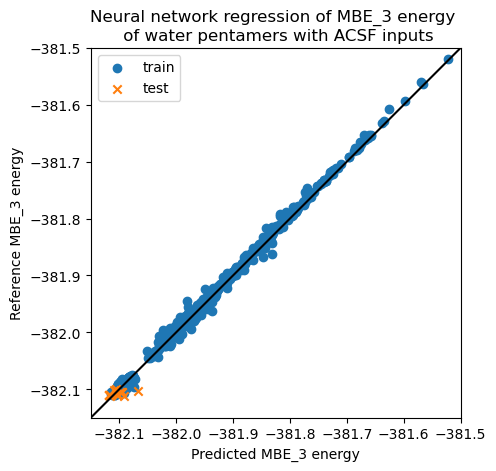

In [32]:
# Show the training and testing results

import matplotlib.pyplot as plt

trans_e_pred_1000_train = []

for struc in strucs_G_train_1000:
    trans_e_pred_1000_train.append(mymodel_mbe3_mixed.forward(struc).detach())
    
trans_e_pred_1000_train = np.asarray(trans_e_pred_1000_train)
e_pred_1000_train = trans_e_pred_1000_train/10.0 - 382.0 

trans_e_pred_test = []

for struc in strucs_G_test:
    trans_e_pred_test.append(mymodel_mbe3_mixed.forward(struc).detach())
    
trans_e_pred_test = np.asarray(trans_e_pred_test)
e_pred_test = trans_e_pred_test/10.0 - 382.0

mbe3_1000_train = trans_mbe3_1000_train/10.0 - 382.0
mbe3_1000_test = trans_mbe3_1000_test/10.0 - 382.0
# plt.scatter(trans_e_pred_100_train.detach().cpu().numpy(), trans_e_100_train, marker = "o", label = "train")
plt.scatter(e_pred_1000_train, mbe3_1000_train, marker = "o", label = "train")
# plt.scatter(trans_e_pred_test.detach().cpu().numpy(), trans_e_test, marker = "x", label = "test")
plt.scatter(e_pred_test, mbe3_1000_test, marker = "x", label = "test")
plt.plot(np.arange(-382.2,-381.0, 0.1), np.arange(-382.2,-381.0, 0.1), color = "black") # the digonal line for reference
plt.xlabel("Predicted MBE_3 energy")
plt.ylabel("Reference MBE_3 energy")
plt.legend()
plt.title("Neural network regression of MBE_3 energy \n of water pentamers with ACSF inputs")
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1.0)
ax.set_xlim([-382.15,-381.5])
ax.set_ylim([-382.15,-381.5])

plt.show()